Found 226 JPG files


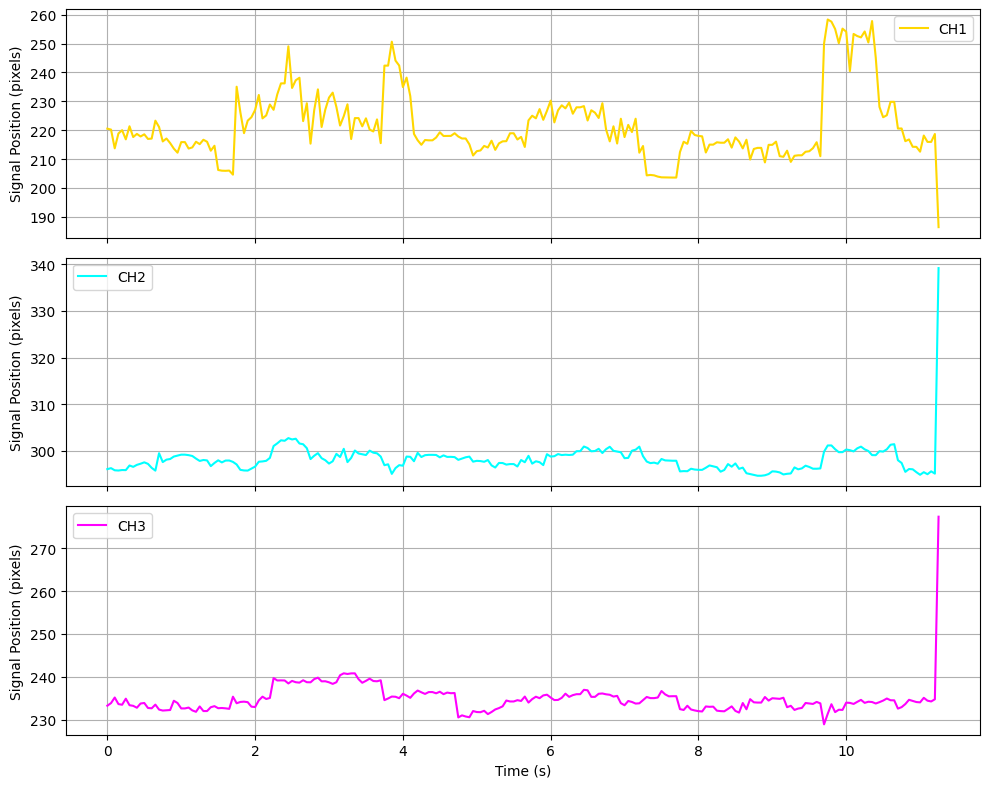

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# Configuration
data_dir = '/Users/xylu/Desktop/Data/Acoustic_local'
fps = 20
time_per_frame = 0.05  # 50ms intervals

# Approximate HSV ranges for Tektronix scope colors
color_ranges = {
    'CH1_Yellow': ([20, 100, 100], [30, 255, 255], 'gold'),
    'CH2_Blue': ([100, 150, 50], [120, 255, 255], 'cyan'),
    'CH3_Pink': ([140, 50, 50], [170, 255, 255], 'magenta')
}

def get_signal_height(img, lower, upper):
    """Get the vertical position (height) of the signal - top to bottom"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    points = np.where(mask > 0)
    if len(points[0]) == 0: return None
    # Return the average Y position (higher value = lower on screen, lower value = higher on screen)
    return np.mean(points[0])

# Sort files by the numeric suffix in your filenames
files = sorted([f for f in os.listdir(data_dir) if f.endswith('.jpg')],
               key=lambda x: int(re.findall(r'\d+', x)[-1]))

print(f"Found {len(files)} JPG files")

results = {'CH1': [], 'CH2': [], 'CH3': [], 'Time': []}

for i, filename in enumerate(files):
    img = cv2.imread(os.path.join(data_dir, filename))
    if img is None:
        continue
    
    results['Time'].append(i * time_per_frame)
    
    for ch, (low, high, color) in color_ranges.items():
        height = get_signal_height(img, low, high)
        results[ch.split('_')[0]].append(height)

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(results['Time'], results['CH1'], color='gold', label='CH1')
ax[1].plot(results['Time'], results['CH2'], color='cyan', label='CH2')
ax[2].plot(results['Time'], results['CH3'], color='magenta', label='CH3')

for a in ax: 
    a.legend()
    a.grid(True)
    a.set_ylabel('Signal Position (pixels)')
    
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

Found 229 files. Image Size: 720x400


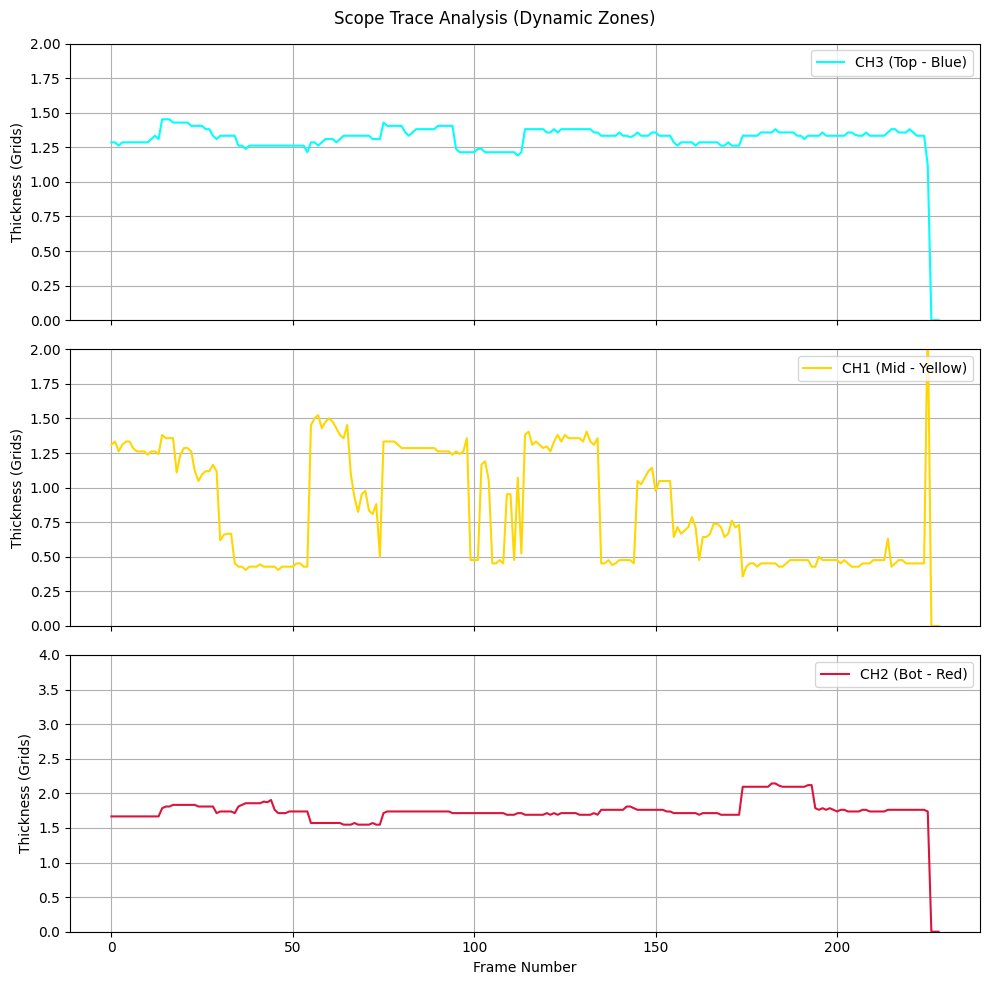

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# --- Configuration ---
data_dir = '/Users/xylu/Desktop/Data/Acoustic_local'

# Calibration: Measure this on your screen!
# (Standard scope image is usually ~42 px per division)
PIXELS_PER_GRID = 42 

# --- ROBUST COLOR RANGES ---
# Saturation/Value lowered to 30 to catch faint/white-ish traces
color_ranges = {
    'CH1': ([15, 30, 30], [45, 255, 255]),     # Yellow (Middle)
    'CH2': ([130, 30, 30], [180, 255, 255]),   # Red/Pink (Bottom)
    'CH3': ([80, 30, 30], [130, 255, 255])     # Blue/Cyan (Top)
}

def get_zone_thickness_dynamic(img, ch_name):
    height, width, _ = img.shape
    
    # --- DEFINE ZONES BY PERCENTAGE ---
    # Top 30% for CH3 (Blue)
    if ch_name == 'CH3':
        y_start = int(height * 0.05) # Skip top 5% menu
        y_end = int(height * 0.35)
        
    # Middle 30% for CH1 (Yellow)
    elif ch_name == 'CH1':
        y_start = int(height * 0.35)
        y_end = int(height * 0.65)
        
    # Bottom 30% for CH2 (Red)
    elif ch_name == 'CH2':
        y_start = int(height * 0.65)
        y_end = int(height * 0.95) # Skip bottom 5% menu

    # Crop to zone (with 50px side margins)
    zone_img = img[y_start:y_end, 50:-50]
    
    # SAFETY CHECK: If zone is empty (e.g. image too small), return 0
    if zone_img.size == 0:
        return 0.0

    # Convert to HSV and Mask
    lower, upper = color_ranges[ch_name]
    hsv = cv2.cvtColor(zone_img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    
    # Clean noise
    kernel = np.ones((2,2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    points = np.where(mask > 0)[0]
    
    if len(points) < 10:
        return 0.0
        
    # Calculate Thickness (10th to 90th percentile)
    top = np.percentile(points, 10)
    bottom = np.percentile(points, 90)
    
    return (bottom - top) / PIXELS_PER_GRID

# --- Main Execution ---
files = sorted(glob.glob(os.path.join(data_dir, "*.jpg")))

if not files:
    print("No images found.")
else:
    # Print image dimensions for debugging
    test_img = cv2.imread(files[0])
    if test_img is not None:
        h, w, _ = test_img.shape
        print(f"Found {len(files)} files. Image Size: {w}x{h}")
    
results = {'CH1': [], 'CH2': [], 'CH3': [], 'Frame': []}

for i, filepath in enumerate(files):
    img = cv2.imread(filepath)
    if img is None: continue
    
    results['Frame'].append(i)
    
    for ch in ['CH3', 'CH1', 'CH2']:
        val = get_zone_thickness_dynamic(img, ch)
        results[ch].append(val)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
plot_configs = {
    'CH3': ('cyan', 'CH3 (Top - Blue)'),
    'CH1': ('gold', 'CH1 (Mid - Yellow)'),
    'CH2': ('crimson', 'CH2 (Bot - Red)')
}

for i, ch in enumerate(['CH3', 'CH1', 'CH2']):
    color, label = plot_configs[ch]
    ax[i].plot(results['Frame'], results[ch], color=color, label=label)
    ax[i].set_ylabel('Thickness (Grids)')
    ax[i].grid(True)
    ax[i].legend(loc='upper right')
    
    # Adjust Y-limits for visibility
    if ch == 'CH2':
        ax[i].set_ylim(0, 4) # Red is thick
    else:
        ax[i].set_ylim(0, 2)

plt.xlabel('Frame Number')
plt.suptitle('Scope Trace Analysis (Dynamic Zones)')
plt.tight_layout()
plt.show()

Processing 229 frames...


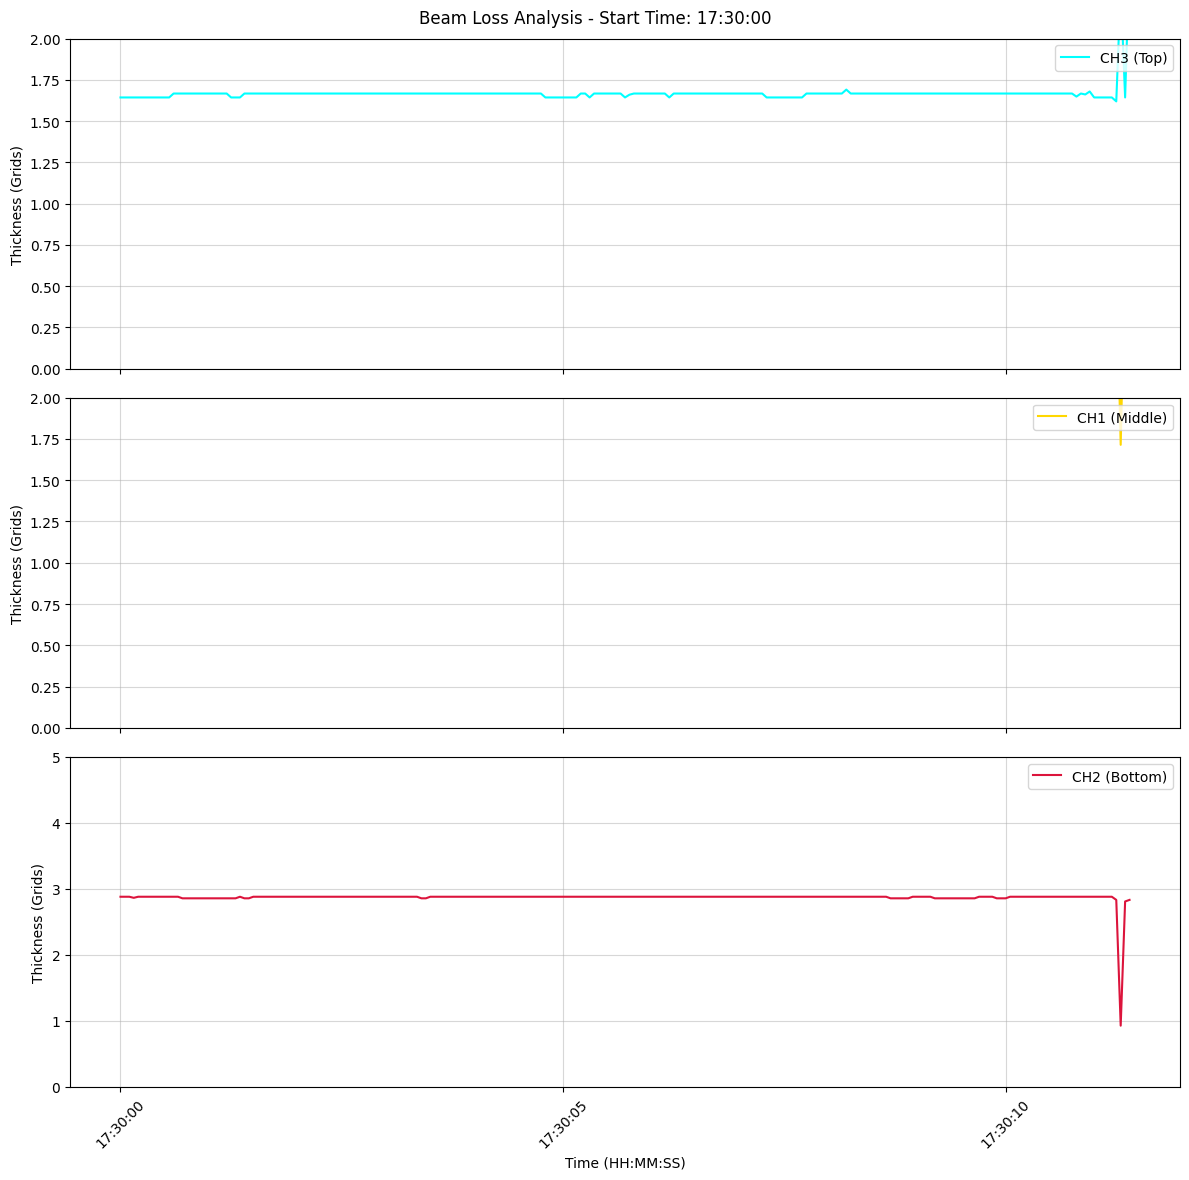

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import glob
from datetime import datetime, timedelta
import re

# --- Configuration ---
data_dir = '/Users/xylu/Desktop/Data/Acoustic_local'
PIXELS_PER_GRID = 42 
BRIGHTNESS_THRESH = 40  # Sensitivity for detecting the signal cloud

# --- SPATIAL ZONES ---
ZONES = {
    'CH3': (0.05, 0.33),  # Top (Blue)
    'CH1': (0.33, 0.64),  # Middle (Yellow)
    'CH2': (0.64, 0.95)   # Bottom (Red)
}

# State variable to fill blanks
last_valid = {'CH1': 0.0, 'CH2': 0.0, 'CH3': 0.0}

def get_cloud_thickness(img_gray, ch_name):
    h, w = img_gray.shape
    y_start_pct, y_end_pct = ZONES[ch_name]
    y0, y1 = int(h * y_start_pct), int(h * y_end_pct)
    
    # Crop and threshold
    zone = img_gray[y0:y1, 50:w-50]
    _, mask = cv2.threshold(zone, BRIGHTNESS_THRESH, 255, cv2.THRESH_BINARY)
    
    # Clean noise
    kernel = np.ones((2,2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Measure
    points = np.where(mask > 0)[0]
    if len(points) < 50: return None
        
    top = np.percentile(points, 2)
    bottom = np.percentile(points, 98)
    return (bottom - top) / PIXELS_PER_GRID

# --- Main Execution ---
files = sorted(glob.glob(os.path.join(data_dir, "*.jpg")))
print(f"Processing {len(files)} frames...")

results = {'CH1': [], 'CH2': [], 'CH3': [], 'Time': []}

# 1. Parse Start Time from the first filename
# Expected format: "2026-02-11 17:30:000003304.jpg" or similar
first_file = os.path.basename(files[0])
try:
    # Regex to find: YYYY-MM-DD and HH:MM
    # Adjust regex if your delimiters are different (e.g. spaces or colons)
    match = re.search(r'(\d{4}-\d{2}-\d{2}).*?(\d{2})[:\uff1a](\d{2})', first_file)
    if match:
        date_str = match.group(1)
        hour = int(match.group(2))
        minute = int(match.group(3))
        start_time = datetime.strptime(f"{date_str} {hour}:{minute}:00", "%Y-%m-%d %H:%M:%S")
    else:
        # Fallback if filename is messy: Use current time or dummy
        start_time = datetime(2026, 2, 11, 17, 30, 0)
        print("Warning: Could not parse time from filename. Using default 17:30:00")
except:
    start_time = datetime(2026, 2, 11, 17, 30, 0)

for i, filepath in enumerate(files):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    
    # Calculate exact time: Start + (Frame Index * 0.05 sec)
    frame_time = start_time + timedelta(seconds=i * 0.05)
    results['Time'].append(frame_time)
    
    for ch in ['CH3', 'CH1', 'CH2']:
        val = get_cloud_thickness(img, ch)
        if val is not None:
            last_valid[ch] = val
        else:
            val = last_valid[ch]
        results[ch].append(val)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

configs = [
    ('CH3', 'cyan', 'CH3 (Top)'),
    ('CH1', 'gold', 'CH1 (Middle)'),
    ('CH2', 'crimson', 'CH2 (Bottom)')
]

for i, (ch, color, label) in enumerate(configs):
    ax[i].plot(results['Time'], results[ch], color=color, label=label, linewidth=1.5)
    ax[i].set_ylabel('Thickness (Grids)')
    ax[i].grid(True, which='both', alpha=0.5)
    ax[i].legend(loc='upper right')
    
    # Format x-axis as Time
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    if ch == 'CH2':
        ax[i].set_ylim(0, 5) 
    else:
        ax[i].set_ylim(0, 2)

plt.xlabel('Time (HH:MM:SS)')
plt.suptitle(f'Beam Loss Analysis - Start Time: {start_time.strftime("%H:%M:%S")}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()